# Schritt 1: Klassifikation von Fashion-MNIST
# Variante B: Dense-Netz mit zwei Hidden Layers und SGD

In diesem Notebook untersuchen wir ein erweitertes neuronales Netz für Fashion-MNIST.

## Ziel

Wir vergleichen:

- ein einfaches Dense-Netz mit einem Hidden Layer (Variante A aus K10_02)
- ein erweitertes Dense-Netz mit zwei Hidden Layers (Variante B)

Zusätzlich betrachten wir den Einfluss des Optimizers:

- Adam (schnell konvergierend)
- SGD (langsamer, aber stabil)

## Lernziele

Nach diesem Notebook sollten Sie:

- den Aufbau eines tieferen Dense-Netzes verstehen
- den Unterschied zwischen SGD und Adam in den Lernkurven erkennen
- beurteilen können, ob mehr Schichten wirklich bessere Ergebnisse liefern

## Vorgehen

1. Fashion-MNIST laden und vorbereiten
2. Variante B definieren, trainieren (SGD) und evaluieren
3. Gleiche Architektur mit Adam trainieren und vergleichen
4. Fazit: Was bringt wirklich bessere Ergebnisse?

## Leitfragen (zum Nachdenken beim Durcharbeiten)

- Macht ein zweiter Hidden Layer das Modell deutlich besser?
- Wie unterscheiden sich Adam und SGD in den Lernkurven?
- Welches Modell würden Sie für Fashion-MNIST empfehlen – und warum?
- Was zeigt die Konfusionsmatrix: Welche Klassen werden verwechselt?

# Schritt 2: Bibliotheken importieren

In [11]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Schritt 3: Fashion-MNIST laden und vorbereiten
## Datenvorbereitung

Wir laden den Fashion-MNIST-Datensatz, skalieren die Pixelwerte auf [0, 1]
und trennen ein Validierungsset ab.

Die Testdaten bleiben bis zur finalen Evaluation unangetastet.

In [13]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=5000, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (55000, 28, 28)
Validation: (5000, 28, 28)
Test: (10000, 28, 28)


# Schritt 4: Klassennamen definieren
## Klassen des Fashion-MNIST-Datensatzes

Zur besseren Interpretation ordnen wir den numerischen Labels ihre Klassennamen zu.

In [14]:
class_names = [
    "T-Shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print(class_names)

['T-Shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Schritt 5: Modell Variante B definieren
## Modell Variante B: zwei Hidden Layers

Wir erweitern das Basismodell um einen zweiten Hidden Layer.

Architektur:

- `Flatten()`
- `Dense(300, ReLU)`
- `Dense(100, ReLU)`
- `Dense(10, Softmax)`

Idee: Ein tieferes Modell kann komplexere Zusammenhänge lernen –
ob das in der Praxis hilft, werden wir messen.

In [15]:
model_sgd = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Schritt 6: Modellüberblick anzeigen
## Modellübersicht

Mit `model.summary()` können wir die Architektur und die Anzahl der Parameter betrachten.

In [16]:
model_sgd.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

# Schritt 7: Manuelle Parameterberechnung
## Parameter selbst nachrechnen

Für jede Dense-Schicht gilt:

`Anzahl_Parameter = Eingaben × Neuronen + Neuronen (Biases)`

Wir rechnen die Parameter manuell nach und vergleichen mit Variante A (K10_02).

In [17]:
# Variante B: Flatten(784) → Dense(300) → Dense(100) → Dense(10)

params_layer1 = 784 * 300 + 300    # Flatten → Dense(300)
params_layer2 = 300 * 100 + 100    # Dense(300) → Dense(100)
params_layer3 = 100 * 10  + 10     # Dense(100) → Dense(10)
total_b = params_layer1 + params_layer2 + params_layer3

print("=== Manuelle Parameterberechnung: Variante B ===")
print(f"Layer 1: Flatten → Dense(300):    784 × 300 + 300 = {params_layer1:>8,}")
print(f"Layer 2: Dense(300) → Dense(100): 300 × 100 + 100 = {params_layer2:>8,}")
print(f"Layer 3: Dense(100) → Dense(10):  100 ×  10 +  10 = {params_layer3:>8,}")
print(f"{'─' * 52}")
print(f"Gesamt:                                          {total_b:>8,}")
print()

# Vergleich mit Variante A aus K10_02 (784 → 128 → 10)
params_a_l1 = 784 * 128 + 128
params_a_l2 = 128 * 10  + 10
total_a = params_a_l1 + params_a_l2

print(f"Zum Vergleich – Variante A (K10_02):   {total_a:,} Parameter")
print(f"Variante B hat {total_b - total_a:,} Parameter mehr.")
print(f"Das entspricht dem {total_b / total_a:.1f}-fachen der Parameter von Variante A.")
print()
print(f"Prüfung mit model.summary() oben: 266.610 ✓")

=== Manuelle Parameterberechnung: Variante B ===
Layer 1: Flatten → Dense(300):    784 × 300 + 300 =  235,500
Layer 2: Dense(300) → Dense(100): 300 × 100 + 100 =   30,100
Layer 3: Dense(100) → Dense(10):  100 ×  10 +  10 =    1,010
────────────────────────────────────────────────────
Gesamt:                                           266,610

Zum Vergleich – Variante A (K10_02):   101,770 Parameter
Variante B hat 164,840 Parameter mehr.
Das entspricht dem 2.6-fachen der Parameter von Variante A.

Prüfung mit model.summary() oben: 266.610 ✓


# Schritt 8: Optimizer SGD erklären
## Optimizer: SGD

Wir verwenden hier bewusst **Stochastic Gradient Descent (SGD)**.

Eigenschaften:

- langsamer als Adam
- oft stabilere, gleichmäßigere Lernkurven
- benötigt mehr Epochen zur Konvergenz

Ziel: Vergleich mit Adam im zweiten Teil dieses Notebooks.

# Schritt 9: Modell mit SGD kompilieren

In [18]:
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 10: Early Stopping definieren
## Early Stopping

Early Stopping beendet das Training automatisch, wenn sich die Leistung
auf den Validierungsdaten nicht weiter verbessert.

Wir verwenden `patience=5` (statt 3), da SGD langsamer konvergiert
und mehr Epochen zum Stabilisieren benötigt.

In [19]:
def make_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

# Schritt 11: SGD-Modell trainieren
## Training des Modells mit SGD

Wir trainieren das Modell auf den Trainingsdaten und überwachen
die Leistung auf dem Validierungsset.

Ein Zeitstempel misst die Trainingsdauer für spätere Vergleiche.

In [20]:
start_time_sgd = time.time()

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

elapsed_sgd = time.time() - start_time_sgd
epochen_sgd = len(history_sgd.history['loss'])
print(f"\nTrainingszeit SGD: {elapsed_sgd:.1f} Sekunden ({epochen_sgd} Epochen)")

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7625 - loss: 0.7221 - val_accuracy: 0.8066 - val_loss: 0.5491
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8307 - loss: 0.4868 - val_accuracy: 0.8246 - val_loss: 0.4858
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8456 - loss: 0.4410 - val_accuracy: 0.8370 - val_loss: 0.4516
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8554 - loss: 0.4133 - val_accuracy: 0.8452 - val_loss: 0.4321
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8623 - loss: 0.3932 - val_accuracy: 0.8530 - val_loss: 0.4131
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8677 - loss: 0.3772 - val_accuracy: 0.8566 - val_loss: 0.3999
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8721 - loss: 0.3637 - val_accuracy: 0.8620 - val_loss: 0.3883
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8753 - loss: 0.3520 - 

# Schritt 12: Lernkurven des SGD-Modells
## Lernkurven: SGD

Wir betrachten:

- Trainings-Loss und Validierungs-Loss
- Trainings-Accuracy und Validierungs-Accuracy

Typisch für SGD: langsamer, gleichmäßigerer Anstieg als Adam.

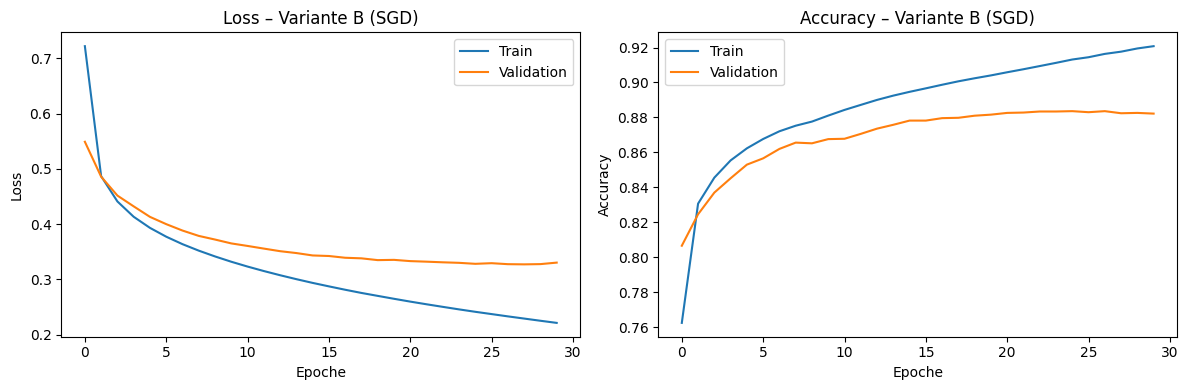

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['loss'], label='Train')
plt.plot(history_sgd.history['val_loss'], label='Validation')
plt.title('Loss – Variante B (SGD)')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['accuracy'], label='Train')
plt.plot(history_sgd.history['val_accuracy'], label='Validation')
plt.title('Accuracy – Variante B (SGD)')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 13: SGD-Modell evaluieren
## Evaluation auf Validierungs- und Testset

In [22]:
val_loss_sgd, val_acc_sgd = model_sgd.evaluate(X_valid, y_valid, verbose=0)
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)

print("Validation-Accuracy (SGD):", val_acc_sgd)
print("Test-Accuracy (Variante B, SGD):", test_acc_sgd)

Validation-Accuracy (SGD): 0.8823999762535095
Test-Accuracy (Variante B, SGD): 0.8834999799728394


# Schritt 14: Konfusionsmatrix des SGD-Modells
## Welche Klassen werden verwechselt?

Die Konfusionsmatrix zeigt, wo das Modell Fehler macht.

Beobachtungsauftrag:
- Welche Klassen werden am häufigsten verwechselt?
- Sind es die gleichen Verwechslungen wie in Variante A (K10_02)?

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


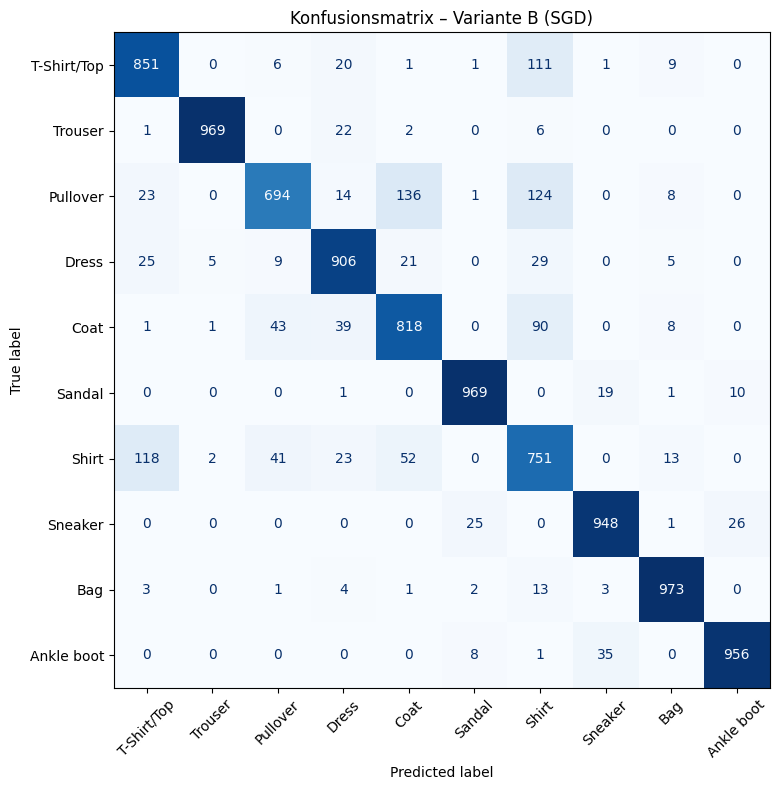

In [23]:
y_pred_sgd = np.argmax(model_sgd.predict(X_test), axis=1)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title("Konfusionsmatrix – Variante B (SGD)")
plt.tight_layout()
plt.show()

# Schritt 15: Zwischenfazit
## Variante B (SGD) vs. Variante A (Adam, K10_02)

Aus dem vorherigen Notebook K10_02:

- Variante A (1 Hidden Layer, Adam): ~88 % Test-Accuracy

Variante B (2 Hidden Layers, SGD):

- Ergebnis: siehe oben

## Leitfrage 1:
Macht ein zweiter Hidden Layer das Modell deutlich besser?

# Schritt 16: Adam vs. SGD – Überleitung
## Vergleich: SGD vs. Adam

Um einen fairen Vergleich zu ermöglichen, trainieren wir **dieselbe Architektur**
(Variante B) auch mit dem Adam-Optimizer.

Erwartete Beobachtungen:

- Adam konvergiert schneller (weniger Epochen nötig)
- SGD hat oft glattere Lernkurven
- Die finale Accuracy kann ähnlich sein

# Schritt 17: Adam-Modell definieren
## Modell mit gleicher Architektur, aber Adam-Optimizer

Die Architektur ist identisch zu Variante B (SGD).
Nur der Optimizer unterscheidet sich.

In [24]:
model_adam = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Schritt 18: Modellüberblick Adam-Modell
## Bestätigung: Gleiche Architektur

Die Parameteranzahl ist identisch mit dem SGD-Modell (266.610) –
nur der Optimizer unterscheidet sich.

In [25]:
model_adam.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

# Schritt 19: Modell mit Adam kompilieren

In [26]:
model_adam.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Schritt 20: Adam-Modell trainieren
## Training mit Adam

Wir verwenden die gleichen Trainingsdaten, Parameter und Early Stopping
wie beim SGD-Modell – damit ist der Vergleich fair.

Ein Zeitstempel ermöglicht den direkten Vergleich der Trainingszeiten.

In [27]:
start_time_adam = time.time()

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    callbacks=[make_early_stop()],
    verbose=1
)

elapsed_adam = time.time() - start_time_adam
epochen_adam = len(history_adam.history['loss'])
print(f"\nTrainingszeit Adam: {elapsed_adam:.1f} Sekunden ({epochen_adam} Epochen)")
print()
print("Vergleich Trainingszeiten:")
print(f"  SGD:  {elapsed_sgd:.1f} s  ({epochen_sgd} Epochen)")
print(f"  Adam: {elapsed_adam:.1f} s  ({epochen_adam} Epochen)")

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8271 - loss: 0.4829 - val_accuracy: 0.8514 - val_loss: 0.4181
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8662 - loss: 0.3629 - val_accuracy: 0.8700 - val_loss: 0.3677
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8810 - loss: 0.3237 - val_accuracy: 0.8734 - val_loss: 0.3480
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8900 - loss: 0.2984 - val_accuracy: 0.8736 - val_loss: 0.3646
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8957 - loss: 0.2787 - val_accuracy: 0.8756 - val_loss: 0.3598
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9013 - loss: 0.2610 - val_accuracy: 0.8802 - val_loss: 0.3588
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9058 - loss: 0.2491 - val_accuracy: 0.8824 - val_loss: 0.3568
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9125 - loss: 0.

# Schritt 21: Lernkurven des Adam-Modells
## Lernkurven: Adam

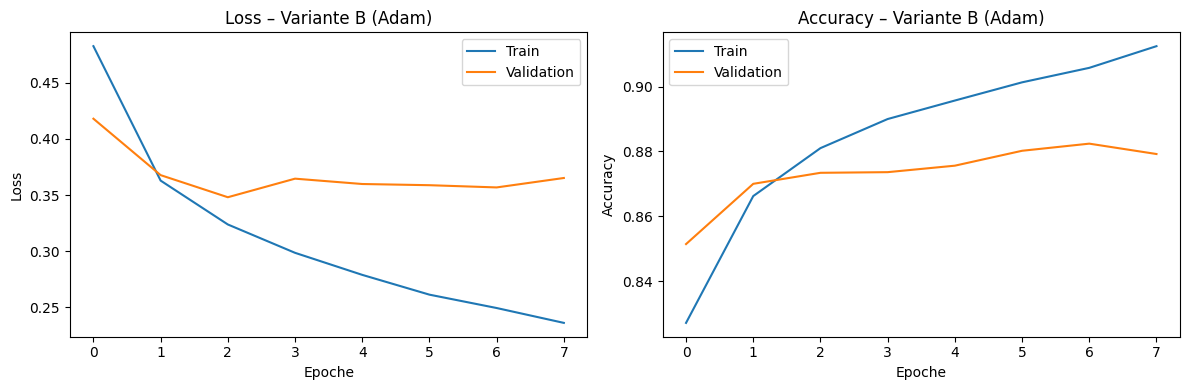

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_adam.history['loss'], label='Train')
plt.plot(history_adam.history['val_loss'], label='Validation')
plt.title('Loss – Variante B (Adam)')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adam.history['accuracy'], label='Train')
plt.plot(history_adam.history['val_accuracy'], label='Validation')
plt.title('Accuracy – Variante B (Adam)')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 22: Adam-Modell evaluieren

In [29]:
val_loss_adam, val_acc_adam = model_adam.evaluate(X_valid, y_valid, verbose=0)
test_loss_adam, test_acc_adam = model_adam.evaluate(X_test, y_test, verbose=0)

print("Validation-Accuracy (Adam):", val_acc_adam)
print("Test-Accuracy (Variante B, Adam):", test_acc_adam)

Validation-Accuracy (Adam): 0.8733999729156494
Test-Accuracy (Variante B, Adam): 0.8715000152587891


# Schritt 23: Direktvergleich der Lernkurven: SGD vs. Adam
## Vergleich der Lernkurven (wichtigster Plot!)

Wir stellen die Lernkurven beider Modelle direkt gegenüber.

Leitfragen:

- Welcher Optimizer lernt schneller?
- Welcher Optimizer ist stabiler?

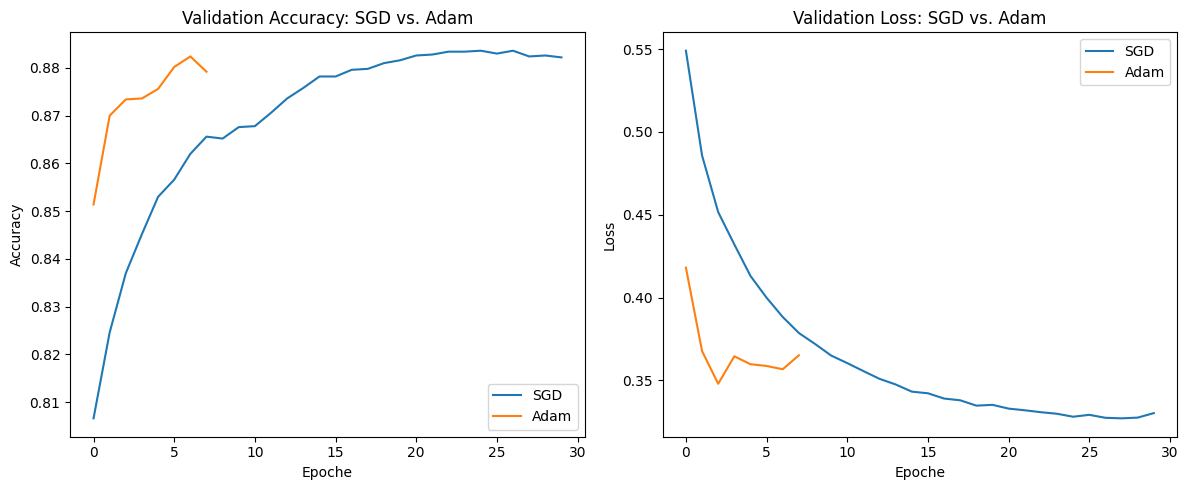

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.title('Validation Accuracy: SGD vs. Adam')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.title('Validation Loss: SGD vs. Adam')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Schritt 24: Alle Ergebnisse im Überblick
## Vergleich aller Modelle

In [31]:
print("=" * 54)
print("Vergleich aller MLP-Modelle auf Fashion-MNIST")
print("=" * 54)
print(f"Variante A (1 Hidden, Adam, K10_02):  ~88.0 %  (Referenz)")
print(f"Variante B (2 Hidden, SGD):            {test_acc_sgd*100:.1f} %")
print(f"Variante B (2 Hidden, Adam):           {test_acc_adam*100:.1f} %")
print()
print("Trainingszeiten (Variante B):")
print(f"  SGD:  {elapsed_sgd:.1f} s  ({epochen_sgd} Epochen)")
print(f"  Adam: {elapsed_adam:.1f} s  ({epochen_adam} Epochen)")

Vergleich aller MLP-Modelle auf Fashion-MNIST
Variante A (1 Hidden, Adam, K10_02):  ~88.0 %  (Referenz)
Variante B (2 Hidden, SGD):            88.3 %
Variante B (2 Hidden, Adam):           87.2 %

Trainingszeiten (Variante B):
  SGD:  230.4 s  (30 Epochen)
  Adam: 84.3 s  (8 Epochen)


In [32]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 5 min 21 sek


# Schritt 25: Interpretation der Ergebnisse
## Interpretation

Typische Beobachtungen:

- Adam konvergiert schneller als SGD (weniger Epochen nötig)
- Die finale Test-Accuracy ist bei beiden ähnlich (~88 %)
- Mehr Schichten (Variante B) bringen gegenüber Variante A kaum Verbesserung

Mögliche Erklärungen für Schwankungen zwischen den Läufen:

- Zufallsinitialisierung der Gewichte
- Unterschiedliches Early-Stopping-Verhalten
- Schwankungen auf den Validierungsdaten

Fazit:
Der Vergleich von Optimierern ist empirisch – Ergebnisse können je nach Lauf variieren.
Für eine zuverlässige Aussage wären mehrere Läufe nötig.

## Leitfrage 3:
Welches Modell würden Sie für Fashion-MNIST empfehlen – und warum?

# Schritt 26: Merksatz
## Merksatz

Dense-Netze stoßen auf Fashion-MNIST an ihre Grenzen – unabhängig davon,
ob 1 oder 2 Hidden Layers verwendet werden, oder ob SGD oder Adam
als Optimizer eingesetzt wird.

**Mehr Schichten und mehr Parameter helfen hier kaum – ein CNN ist die bessere Lösung.**

Im nächsten Notebook (K10_04) zeigen wir, dass ein CNN mit der Architektur
`Conv2D → MaxPool → Conv2D → MaxPool → Flatten → Dense`
deutlich bessere Ergebnisse (~91–93 % Test-Accuracy) erreicht.